In [1]:
import pandas as pd 
import numpy as np
import geopandas as gpd
import os

In [2]:
os.getcwd()

'c:\\Users\\Usuario\\OneDrive - Global Green Growth Institute\\Documentos\\2025\\Outputs\\Output1\\Stress Test\\3.Data\\Scripts Python\\scripts_python'

In [3]:
import unicodedata

def normalizar(s):
    s = str(s).strip().upper()
    s = unicodedata.normalize("NFD", s)
    return "".join(c for c in s if unicodedata.category(c) != "Mn")

# ── Carga emergencias ─────────────────────────────────────────────────────
OUTPUT4 = r"C:\Users\Usuario\OneDrive - Global Green Growth Institute\Documentos\2025\Outputs\Output4"

emergencias = pd.read_excel(
    os.path.join(OUTPUT4, "REPORTE-ANUAL-DE-EMERGENCIAS-2024.xlsx")
)

emergencias = emergencias.rename(columns={"CODIFICACIÓN SEGUN DIVIPOLA": "COD_MPIO"})
emergencias["amenaza_limpia"] = emergencias["EVENTO"].apply(normalizar)

print(f"Registros emergencias: {len(emergencias):,}")
emergencias[["COD_MPIO", "EVENTO", "amenaza_limpia"]].head(10)

Registros emergencias: 10,587


,COD_MPIO,EVENTO,amenaza_limpia
0,68547,INCENDIO FORESTAL,INCENDIO FORESTAL
1,25841,ACCIDENTE TRANSPORTE TERRESTRE,ACCIDENTE TRANSPORTE TERRESTRE
2,66001,INCENDIO FORESTAL,INCENDIO FORESTAL
3,41551,INCENDIO ESTRUCTURAL,INCENDIO ESTRUCTURAL
4,23001,INCENDIO ESTRUCTURAL,INCENDIO ESTRUCTURAL
5,5154,INCENDIO ESTRUCTURAL,INCENDIO ESTRUCTURAL
6,41524,MOVIMIENTO EN MASA,MOVIMIENTO EN MASA
7,66572,CASO FORTUITO,CASO FORTUITO
8,15861,ACCIDENTE TRANSPORTE TERRESTRE,ACCIDENTE TRANSPORTE TERRESTRE
9,47001,INCENDIO FORESTAL,INCENDIO FORESTAL


In [4]:
# ── Filtro eventos de precipitación ──────────────────────────────────────
emergencias['precip_event'] = 'NONE'

# Flood (exceso de lluvia)
emergencias.loc[
    emergencias['amenaza_limpia'].isin([
        'INUNDACION',
        'CRECIENTE SUBITA',
        'AVENIDA TORRENCIAL'
    ]),
    'precip_event'
] = 'FLOOD'

# Drought (déficit de lluvia)
emergencias.loc[
    emergencias['amenaza_limpia'] == 'SEQUIA',
    'precip_event'
] = 'DROUGHT'

emergencias_precip = emergencias[emergencias['precip_event'] != 'NONE'].copy()

print(f"Eventos de precipitación: {len(emergencias_precip):,} de {len(emergencias):,}")
print(emergencias_precip['precip_event'].value_counts().to_string())

Eventos de precipitación: 852 de 10,587
precip_event
FLOOD      821
DROUGHT     31


In [5]:
# ── Agrupar emergencias FLOOD por municipio (1 fila por municipio) ─────────
for col in ["MUERTOS", "HERIDOS", "PERSONAS", "FAMILIAS"]:
    emergencias_precip[col] = pd.to_numeric(emergencias_precip[col], errors="coerce")

emergencias_mpio = (
    emergencias_precip[emergencias_precip["precip_event"] == "FLOOD"]
    .groupby("COD_MPIO", as_index=False)
    .agg(
        n_eventos_flood  = ("precip_event",  "count"),
        muertos_total    = ("MUERTOS",       "sum"),
        heridos_total    = ("HERIDOS",       "sum"),
        personas_total   = ("PERSONAS",      "sum"),
        familias_total   = ("FAMILIAS",      "sum"),
        fecha_primer_ev  = ("FECHA",         "min"),
        fecha_ultimo_ev  = ("FECHA",         "max"),
    )
)

emergencias_mpio["COD_MPIO"] = pd.to_numeric(emergencias_mpio["COD_MPIO"], errors="coerce")

print(f"Municipios con al menos 1 evento FLOOD: {len(emergencias_mpio):,}")
emergencias_mpio.head()

Municipios con al menos 1 evento FLOOD: 410


,COD_MPIO,n_eventos_flood,muertos_total,heridos_total,personas_total,familias_total,fecha_primer_ev,fecha_ultimo_ev
0,27,1,0.0,0.0,0.0,0.0,2024-01-15,2024-01-15
1,54,2,0.0,0.0,0.0,0.0,2024-10-30,2024-10-30
2,68,3,0.0,0.0,0.0,0.0,2024-10-29,2024-10-29
3,85,1,0.0,0.0,3158.0,1378.0,2024-09-18,2024-09-18
4,5001,4,0.0,5.0,0.0,0.0,2024-05-14,2024-11-10


In [6]:
# ── Right merge: alertas_historica (todos los municipios) ← emergencias ───
WEB_DATA_DIR = r"C:\Users\Usuario\OneDrive - Global Green Growth Institute\Documentos\2025\Outputs\Output1\Stress Test\3.Data\Scripts Python\webpage_climate\data"

alertas = pd.read_csv(os.path.join(WEB_DATA_DIR, "alerta_historica_municipal.csv"))
alertas["COD_MPIO"] = pd.to_numeric(alertas["COD_MPIO"], errors="coerce")

base_modelo = pd.merge(
    emergencias_mpio,
    alertas,
    on="COD_MPIO",
    how="right"
)

# Municipios sin emergencias registradas quedan con n_eventos_flood = 0
base_modelo["n_eventos_flood"] = base_modelo["n_eventos_flood"].fillna(0).astype(int)
base_modelo["flood_ocurrido"]  = (base_modelo["n_eventos_flood"] > 0).astype(int)

print(f"Total municipios en base modelo  : {len(base_modelo):,}")
print(f"  Con eventos FLOOD              : {base_modelo['flood_ocurrido'].sum():,}")
print(f"  Sin eventos FLOOD              : {(base_modelo['flood_ocurrido'] == 0).sum():,}")
base_modelo.head(10)

Total municipios en base modelo  : 587
  Con eventos FLOOD              : 253
  Sin eventos FLOOD              : 334


,COD_MPIO,n_eventos_flood,muertos_total,heridos_total,personas_total,familias_total,fecha_primer_ev,fecha_ultimo_ev,COD_DPTO,NOM_DPTO,NOM_MPIO,frecuencia_extremos,frecuencia_reciente,ratio_reciente,tendencia,alerta_lluvias,sequia_categoria,n_estaciones,sequia_nivel,flood_ocurrido
0,5001,4,0.0,5.0,0.0,0.0,2024-05-14,2024-11-10,5,ANTIOQUIA,MEDELLÍN,0.250000,0.204303,5.135190,estable,ALTA,NORMAL,8,0,1
1,5004,0,NaN,NaN,NaN,NaN,NaT,NaT,5,ANTIOQUIA,ABRIAQUÍ,0.194286,0.113302,2.028106,decreciente,BAJA,MODERADA,4,2,0
2,5031,0,NaN,NaN,NaN,NaN,NaT,NaT,5,ANTIOQUIA,AMALFI,0.113402,0.148851,1.312597,estable,CRÍTICA,MODERADA,3,2,0
3,5034,1,0.0,0.0,0.0,0.0,2024-05-15,2024-05-15,5,ANTIOQUIA,ANDES,0.104252,NaN,NaN,sin_datos,ALTA,NORMAL,2,0,1
4,5038,0,NaN,NaN,NaN,NaN,NaT,NaT,5,ANTIOQUIA,ANGOSTURA,0.173184,0.224175,2.258639,estable,BAJA,NORMAL,6,0,0
5,5040,4,0.0,0.0,0.0,0.0,2024-05-30,2024-11-08,5,ANTIOQUIA,ANORÍ,0.107558,0.104671,0.973158,estable,ALTA,MODERADA,2,2,1
6,5042,0,NaN,NaN,NaN,NaN,NaT,NaT,5,ANTIOQUIA,SANTA FÉ DE ANTIOQUIA,0.207547,0.208042,3.777610,estable,ALTA,NORMAL,6,0,0
7,5045,1,0.0,0.0,0.0,0.0,2024-05-02,2024-05-02,5,ANTIOQUIA,APARTADÓ,0.136364,0.158561,1.599248,insuficiente,CRÍTICA,NORMAL,4,0,1
8,5055,0,NaN,NaN,NaN,NaN,NaT,NaT,5,ANTIOQUIA,ARGELIA,0.365079,0.332386,4.163227,estable,BAJA,NORMAL,4,0,0
9,5059,0,NaN,NaN,NaN,NaN,NaT,NaT,5,ANTIOQUIA,ARMENIA,0.108883,0.131190,1.204875,decreciente,CRÍTICA,NORMAL,2,0,0


In [7]:
base_modelo_=base_modelo[["flood_ocurrido",'frecuencia_extremos','frecuencia_reciente','ratio_reciente','tendencia','alerta_lluvias']]
base_modelo_.head()

,flood_ocurrido,frecuencia_extremos,frecuencia_reciente,ratio_reciente,tendencia,alerta_lluvias
0,1,0.250000,0.204303,5.135190,estable,ALTA
1,0,0.194286,0.113302,2.028106,decreciente,BAJA
2,0,0.113402,0.148851,1.312597,estable,CRÍTICA
3,1,0.104252,NaN,NaN,sin_datos,ALTA
4,0,0.173184,0.224175,2.258639,estable,BAJA


In [8]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install scikit-learn xgboost matplotlib

Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [11]:
import importlib
import sklearn, xgboost
importlib.reload(sklearn)
importlib.reload(xgboost)
print("sklearn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)

sklearn: 1.8.0
xgboost: 3.2.0


Nulos tras imputación: 0

Correlación con target (post feature engineering):
target                 1.0000
ratio_x_extremos       0.0933
frecuencia_extremos    0.0859
ratio_reciente         0.0837
reciente_x_extremos    0.0684
frecuencia_reciente    0.0652
tendencia              0.0219
diff_reciente         -0.0533
alerta_lluvias        -0.0769
Name: target, dtype: float64

       MÉTRICAS DE EVALUACIÓN
  Accuracy           : 0.5678
  F1-Score (binary)  : 0.5143
  F1-Score (macro)   : 0.5625
  Precision          : 0.5000
  Recall             : 0.5294
  ROC-AUC            : 0.5525
              precision    recall  f1-score   support

    No Flood       0.62      0.60      0.61        67
       Flood       0.50      0.53      0.51        51

    accuracy                           0.57       118
   macro avg       0.56      0.56      0.56       118
weighted avg       0.57      0.57      0.57       118

CV F1 (5-fold): [0.4528 0.434  0.4301 0.3564 0.4118]
Media: 0.4170 ± 0.0330


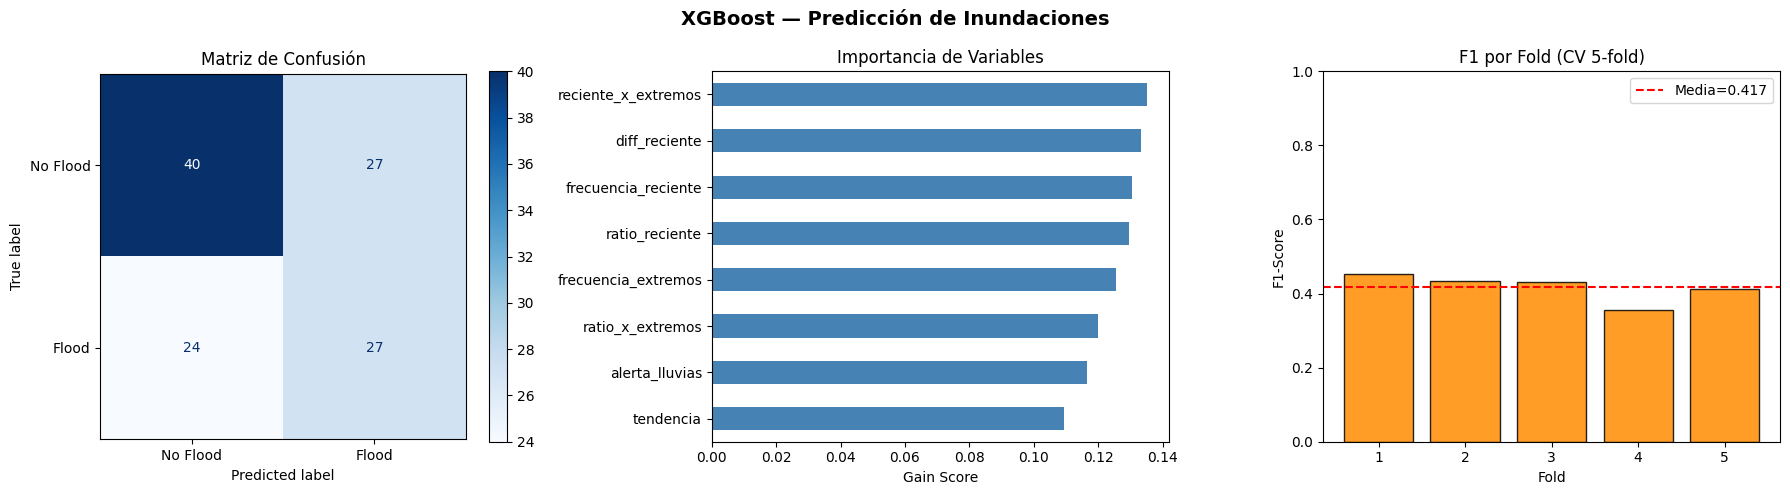

In [15]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    f1_score, classification_report,
    roc_auc_score, precision_score, recall_score, accuracy_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# PREPARACIÓN
# ─────────────────────────────────────────────
base_modelo_ = base_modelo[[
    "flood_ocurrido", "frecuencia_extremos", "frecuencia_reciente",
    "ratio_reciente", "tendencia", "alerta_lluvias"
]].copy()

X = base_modelo_.drop(columns=["flood_ocurrido"])
y = base_modelo_["flood_ocurrido"]

# ─────────────────────────────────────────────
# ENCODING CATEGÓRICAS
# ─────────────────────────────────────────────
cat_cols = ["tendencia", "alerta_lluvias"]
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# ─────────────────────────────────────────────
# IMPUTACIÓN DE NULOS (mediana por ser robusta a outliers)
# ─────────────────────────────────────────────
num_cols = ["frecuencia_extremos", "frecuencia_reciente", "ratio_reciente"]
imputer = SimpleImputer(strategy="median")
X[num_cols] = imputer.fit_transform(X[num_cols])

print("Nulos tras imputación:", X.isnull().sum().sum())

# ─────────────────────────────────────────────
# FEATURE ENGINEERING — nuevas variables
# ─────────────────────────────────────────────
X["ratio_x_extremos"]    = X["ratio_reciente"]      * X["frecuencia_extremos"]
X["reciente_x_extremos"] = X["frecuencia_reciente"] * X["frecuencia_extremos"]
X["diff_reciente"]       = X["frecuencia_reciente"] - X["frecuencia_extremos"]

# Correlación actualizada
temp = X.copy()
temp["target"] = y.values
print("\nCorrelación con target (post feature engineering):")
print(temp.corr()["target"].sort_values(ascending=False).round(4))

# ─────────────────────────────────────────────
# SPLIT
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

# ─────────────────────────────────────────────
# MODELO
# ─────────────────────────────────────────────
model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# ─────────────────────────────────────────────
# MÉTRICAS
# ─────────────────────────────────────────────
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\n" + "="*50)
print("       MÉTRICAS DE EVALUACIÓN")
print("="*50)
print(f"  Accuracy           : {accuracy_score(y_test, y_pred):.4f}")
print(f"  F1-Score (binary)  : {f1_score(y_test, y_pred):.4f}")
print(f"  F1-Score (macro)   : {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"  Precision          : {precision_score(y_test, y_pred):.4f}")
print(f"  Recall             : {recall_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC            : {roc_auc_score(y_test, y_proba):.4f}")
print("="*50)
print(classification_report(y_test, y_pred, target_names=["No Flood", "Flood"]))

# ─────────────────────────────────────────────
# CROSS-VALIDATION
# ─────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1 = cross_val_score(model, X, y, cv=cv, scoring="f1", n_jobs=-1)
print(f"CV F1 (5-fold): {np.round(cv_f1, 4)}")
print(f"Media: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

# ─────────────────────────────────────────────
# VISUALIZACIONES
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("XGBoost — Predicción de Inundaciones", fontsize=14, fontweight="bold")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["No Flood", "Flood"],
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Matriz de Confusión")

feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
feat_imp.plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Importancia de Variables")
axes[1].set_xlabel("Gain Score")

axes[2].bar(range(1, 6), cv_f1, color="darkorange", edgecolor="black", alpha=0.85)
axes[2].axhline(cv_f1.mean(), color="red", linestyle="--", label=f"Media={cv_f1.mean():.3f}")
axes[2].set_title("F1 por Fold (CV 5-fold)")
axes[2].set_xlabel("Fold"); axes[2].set_ylabel("F1-Score")
axes[2].legend(); axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()